In [20]:
!pip install langchain langchain-core langchain-google-genai langchain-community langchain-groq

In [21]:
print("Hello Rajneet!")

Hello Rajneet!


In [22]:
import pandas as pd
import numpy as np
import re
from collections import Counter

In [23]:
import os

os.getcwd()

'/content'

In [24]:
os.listdir()

['.config', 'sample_data']

In [25]:
import os

os.listdir()

['.config', 'sample_data']

In [26]:
import pandas as pd
import numpy as np
import re
from collections import Counter

In [27]:
df = pd.read_csv("/Meesho.csv")

#### # Customer Feedback Analysis and Automated Response

### Imarticus Data Science Internship Assessment

**Dataset:** Meesho Customer Reviews

#### # Data Loading

In this step, the Meesho customer review dataset is loaded into a Pandas DataFrame for further analysis.

#### # Data Exploration

The first few rows of the dataset are displayed to understand its structure and verify that the data has been loaded correctly.

In [28]:
df.head()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName
0,71f2dd28-b125-4baa-9318-b1ade4014d7c,"worst app i have used so far, for shopping. so...",1,337,1697744361000,"Hi, thank you so much for bringing this issue ...",1.697746e+12,Meesho
1,456f060f-055d-42ec-af81-5cd986ccc6cd,"Hi meesho, I was unable to open the app. when ...",4,0,1692755258000,"Hi, We’d just like to thank you for taking the...",1.692756e+12,Meesho
2,d1467361-fb6b-4089-b70f-1e6d11cb8c64,Worst experience with the app. Out of my 4 ord...,1,74,1634896280000,"Hello, we are sorry to learn that you had an u...",1.634742e+12,Meesho
3,e583d050-b1a8-4072-adbb-7d335e3b4072,Abstly amazing. Products at convenient prices....,5,3684,1722424087000,"Hi, We’d just like to thank you for taking the...",1.722426e+12,Meesho
4,c6143a4c-d3fd-45a5-ba75-932e006573fc,"Very good , but we order two quantity they sen...",4,123,1723334324000,"Hi, We’d just like to thank you for taking the...",1.723336e+12,Meesho


In [29]:
df.tail()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName
35995,938b3e09-1822-4e3f-bdbc-896923a2bae9,Decent app. Fast delivery. Reasonable prices. ...,4,11,1644340636000,"Hi, We’d just like to thank you for taking the...",1.644345e+12,Meesho
35996,82d04dbf-8432-4f95-89ac-7d4dbace1dde,I love this app but why the size charts are no...,4,10,1643824305000,"Hi, We’d just like to thank you for taking the...",1.643826e+12,Meesho
35997,8a15b5d4-de14-4a57-97b9-bee4f2e1c5f8,The App is too good but can't select multiple ...,5,9,1633782013000,NaN,NaN,Meesho
35998,7eca21f5-2f48-4325-a2c4-623a1beb9aae,This is very nice Reselling app. Good quality ...,5,2,1616787795000,"Hello Entrepreneur, Thank you for appreciating...",1.616942e+12,Meesho
35999,86bd13bc-0e4e-4efb-880f-28c9ac7466dc,very low quality and duplicate products. Very ...,1,0,1699572228000,"Hi, Thanks so much for bringing this issue to ...",1.699573e+12,Meesho


In [30]:
df.shape

(36000, 8)

In [31]:
df.columns

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'at', 'replyContent',
       'repliedAt', 'appName'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewId       36000 non-null  object 
 1   content        36000 non-null  object 
 2   score          36000 non-null  int64  
 3   thumbsUpCount  36000 non-null  int64  
 4   at             36000 non-null  int64  
 5   replyContent   34875 non-null  object 
 6   repliedAt      34875 non-null  float64
 7   appName        36000 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.2+ MB


In [33]:
df.isnull().sum()

,0
reviewId,0
content,0
score,0
thumbsUpCount,0
at,0
replyContent,1125
repliedAt,1125
appName,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df = df.drop_duplicates()

#### Understanding the Dataset

In this section, the dataset's dimensions, column names, data types, and missing values are examined.

In [36]:
df.shape

(36000, 8)

#### # Data Cleaning

The dataset is cleaned by selecting the required columns, handling missing values, and preparing the review text for further analysis.

In [37]:
df = df[['content', 'score']]

In [38]:
df.head()

,content,score
0,"worst app i have used so far, for shopping. so...",1
1,"Hi meesho, I was unable to open the app. when ...",4
2,Worst experience with the app. Out of my 4 ord...,1
3,Abstly amazing. Products at convenient prices....,5
4,"Very good , but we order two quantity they sen...",4


In [39]:
df.rename(columns={
    "content": "Review",
    "score": "Rating"
}, inplace=True)

In [40]:
df.head()

,Review,Rating
0,"worst app i have used so far, for shopping. so...",1
1,"Hi meesho, I was unable to open the app. when ...",4
2,Worst experience with the app. Out of my 4 ord...,1
3,Abstly amazing. Products at convenient prices....,5
4,"Very good , but we order two quantity they sen...",4


In [41]:
df.isnull().sum()

,0
Review,0
Rating,0


#### # Text Data Cleaning

In this step, the review text is cleaned by converting it to lowercase, removing special characters, and removing extra spaces. This prepares the data for further analysis.

In [42]:
df["Review"].head()

,Review
0,"worst app i have used so far, for shopping. so..."
1,"Hi meesho, I was unable to open the app. when ..."
2,Worst experience with the app. Out of my 4 ord...
3,Abstly amazing. Products at convenient prices....
4,"Very good , but we order two quantity they sen..."


In [43]:
df["Review"] = df["Review"].str.lower()

In [44]:
df["Review"].head()

,Review
0,"worst app i have used so far, for shopping. so..."
1,"hi meesho, i was unable to open the app. when ..."
2,worst experience with the app. out of my 4 ord...
3,abstly amazing. products at convenient prices....
4,"very good , but we order two quantity they sen..."


In [45]:
df["Review"] = df["Review"].str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)

In [46]:
df["Review"] = df["Review"].str.strip()

In [47]:
df["Review"].head()

,Review
0,worst app i have used so far for shopping some...
1,hi meesho i was unable to open the app when i ...
2,worst experience with the app out of my 4 orde...
3,abstly amazing products at convenient prices i...
4,very good but we order two quantity they send...


In [48]:
df.to_csv("Cleaned_Meesho_Reviews.csv", index=False)

In [49]:
critical_reviews = df[df["Rating"] <= 2]

In [50]:
df["Review"].head()

,Review
0,worst app i have used so far for shopping some...
1,hi meesho i was unable to open the app when i ...
2,worst experience with the app out of my 4 orde...
3,abstly amazing products at convenient prices i...
4,very good but we order two quantity they send...


#### # Rule-Based Filtering of Critical Reviews

In this step, reviews with a rating of 1 or 2 are filtered and identified as critical reviews. This is done using simple Python logic without any machine learning model.

In [51]:
critical_reviews = df[df["Rating"] <= 2]

In [52]:
critical_reviews.shape

(22828, 2)

In [53]:
critical_reviews.head()

,Review,Rating
0,worst app i have used so far for shopping some...,1
2,worst experience with the app out of my 4 orde...,1
5,the download option gets below the screen on t...,2
6,the worst app all of a sudden the app couldnt ...,1
7,its fraud shopping app showing user verificati...,1


In [54]:
critical_reviews["Rating"].value_counts()

,count
Rating,
1,21153
2,1675


#### # Finding the Most Common Complaint Keywords

In this step, the most frequently occurring words in critical customer reviews are identified using Python's Counter class. This helps understand the common issues faced by customers.

In [55]:
text = " ".join(critical_reviews["Review"])

In [56]:
words = text.split()

In [57]:
word_count = Counter(words)

In [58]:
word_count.most_common(20)

[('the', 46223),
 ('i', 44457),
 ('and', 36057),
 ('to', 29405),
 ('is', 25595),
 ('they', 23927),
 ('app', 22029),
 ('not', 20128),
 ('this', 17715),
 ('my', 17347),
 ('product', 17316),
 ('it', 17214),
 ('but', 16393),
 ('a', 15976),
 ('of', 14463),
 ('for', 13864),
 ('order', 12501),
 ('meesho', 12336),
 ('have', 11875),
 ('customer', 10893)]

In [59]:
stop_words = {
    "the","is","a","an","and","or","to","of","in","on","for",
    "my","i","it","this","that","was","are","be","have","has",
    "had","with","very","so","they","you","we","me","our",
    "your","at","from","as","but","if","not","do","did"
}

In [60]:
filtered_words = [word for word in words if word not in stop_words]

In [61]:
filtered_count = Counter(filtered_words)

In [62]:
filtered_count.most_common(20)

[('app', 22029),
 ('product', 17316),
 ('order', 12501),
 ('meesho', 12336),
 ('customer', 10893),
 ('worst', 10774),
 ('dont', 9027),
 ('return', 9015),
 ('delivery', 8752),
 ('no', 7488),
 ('will', 7153),
 ('its', 6781),
 ('service', 6651),
 ('time', 6487),
 ('refund', 6240),
 ('ordered', 6216),
 ('money', 6050),
 ('products', 5903),
 ('one', 5792),
 ('when', 5692)]

In [63]:
filtered_count.most_common(20)

[('app', 22029),
 ('product', 17316),
 ('order', 12501),
 ('meesho', 12336),
 ('customer', 10893),
 ('worst', 10774),
 ('dont', 9027),
 ('return', 9015),
 ('delivery', 8752),
 ('no', 7488),
 ('will', 7153),
 ('its', 6781),
 ('service', 6651),
 ('time', 6487),
 ('refund', 6240),
 ('ordered', 6216),
 ('money', 6050),
 ('products', 5903),
 ('one', 5792),
 ('when', 5692)]

#### # Complaint Keyword Analysis

The most common complaint keywords are extracted from critical customer reviews using Python's Counter class after removing common stop words.

In [64]:
text = " ".join(critical_reviews["Review"])

In [65]:
words = text.split()

In [66]:
from collections import Counter

In [67]:
stop_words = {
    "the","is","a","an","and","or","to","of","in","on","for",
    "my","i","it","this","that","was","are","be","have","has",
    "had","with","very","so","they","you","we","me","our",
    "your","at","from","as","but","if","not","do","did",
    "app","meesho","order","product"
}

In [68]:
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

In [69]:
filtered_count = Counter(filtered_words)

In [70]:
filtered_count.most_common(20)

[('customer', 10893),
 ('worst', 10774),
 ('dont', 9027),
 ('return', 9015),
 ('delivery', 8752),
 ('will', 7153),
 ('its', 6781),
 ('service', 6651),
 ('time', 6487),
 ('refund', 6240),
 ('ordered', 6216),
 ('money', 6050),
 ('products', 5903),
 ('one', 5792),
 ('when', 5692),
 ('bad', 5655),
 ('even', 5273),
 ('also', 5230),
 ('after', 5187),
 ('experience', 5116)]

#### # Selecting Critical Reviews

The three most critical customer reviews are selected for generating personalized apology emails using Generative AI.

In [71]:
top_reviews = critical_reviews.head(3)
top_reviews

,Review,Rating
0,worst app i have used so far for shopping some...,1
2,worst experience with the app out of my 4 orde...,1
5,the download option gets below the screen on t...,2


In [72]:
stop_words.update({
    "customer","dont","don't","will","its","one",
    "when","also","even","after","ordered",
    "products","time","experience"
})

In [73]:
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

filtered_count = Counter(filtered_words)

filtered_count.most_common(20)

[('worst', 10774),
 ('return', 9015),
 ('delivery', 8752),
 ('service', 6651),
 ('refund', 6240),
 ('money', 6050),
 ('bad', 5655),
 ('any', 5085),
 ('delivered', 4859),
 ('care', 4573),
 ('now', 4457),
 ('get', 4408),
 ('days', 4216),
 ('didnt', 4167),
 ('all', 4119),
 ('received', 3960),
 ('call', 3885),
 ('there', 3877),
 ('then', 3834),
 ('ever', 3799)]

In [74]:
!pip install langchain laangchain-core langchain-google-genai langchain-community langchai

ERROR: Could not find a version that satisfies the requirement laangchain-core (from versions: none)
ERROR: No matching distribution found for laangchain-core


In [75]:
!pip install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.2/984.2 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.10.0
    Uninstalling google-genai-2.10.0:
      Successfully uninstalled google-genai-2.10.0


In [76]:
# from google import genai
from langchain_google_genai import ChatGoogleGenerativeAI

In [77]:
import google.generativeai as genai

genai.configure(api_key="AQ.Ab8RN6LQIffEcm45g1v5_kv-6VuRUedRfhJ7rEOXOYQ6joHg1A")

model = genai.GenerativeModel("gemini-2.5-flash")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [80]:
top_reviews = critical_reviews.head(3)

In [81]:
top_reviews

,Review,Rating
0,worst app i have used so far for shopping some...,1
2,worst experience with the app out of my 4 orde...,1
5,the download option gets below the screen on t...,2


In [87]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    api_key="AQ.Ab8RN6LQIffEcm45g1v5_kv-6VuRUedRfhJ7rEOXOYQ6joHg1A")

In [88]:
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

In [89]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template("""
Role:
You are an experienced Customer Support Agent for Meesho.

Task:
Generate a short, personalized, professional and empathetic apology email.

Customer Review:
{Review}

Instructions:

- Begin with a sincere apology.
- Address the customer's complaint mentioned in the review.
- Show empathy.
- Assure the customer that the issue will be investigated.
- Thank the customer for sharing feedback.
- Keep the email between 80 and 120 words.

Output Format:

Subject: We're Sorry About Your Experience

Dear Customer,

<Generate the email here>

Best Regards,

Meesho Customer Support Team
""")

In [90]:
from google.colab import userdata
import os
# Replace 'GROQ_API_KEY' with the name you gave your secret in the Secrets Manager
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

print("API key loaded successfully!")

API key loaded successfully!


After loading the API key, you can then update your `ChatGroq` initialization to use this variable:

In [94]:
df.head

<bound method NDFrame.head of                                                   Review  Rating
0      worst app i have used so far for shopping some...       1
1      hi meesho i was unable to open the app when i ...       4
2      worst experience with the app out of my 4 orde...       1
3      abstly amazing products at convenient prices i...       5
4      very good  but we order two quantity they send...       4
...                                                  ...     ...
35995  decent app fast delivery reasonable prices lot...       4
35996  i love this app but why the size charts are no...       4
35997  the app is too good but cant select multiple o...       5
35998  this is very nice reselling app good quality  ...       5
35999  very low quality and duplicate products very b...       1

[36000 rows x 2 columns]>

In [91]:
from langchain_groq import ChatGroq
import os

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    api_key=os.environ.get('GROQ_API_KEY') # Use the key loaded from Secrets Manager
)

# Now, re-run the chain with the correctly configured LLM
chain = prompt | llm | parser

review = critical_reviews.iloc[0]["Review"]

# Assuming 'critical_reviews' and 'prompt' and 'parser' are defined from previous cells
# If not, you might need to re-execute those cells before this one.
res = chain.invoke({
    "Review": review
})

print(res)

Subject: We're Sorry About Your Experience

Dear Customer,

We apologize for the disappointing experience with our app. We understand your concern about receiving fake or low-quality products. We empathize with the frustration this has caused. We will investigate this issue and take necessary actions. Thank you for sharing your feedback, which helps us improve.

Best Regards,
Meesho Customer Support Team


In [96]:
chain = prompt | llm | parser

review = critical_reviews.iloc[1]["Review"]

res = chain.invoke({
    "Review": review
})

print(res)

Subject: We're Sorry About Your Experience

Dear Customer,

We sincerely apologize for the poor experience you had with our app. We're deeply sorry to hear that out of your 4 orders, only one was satisfactory, and you faced issues with delivery and refunds. We understand your frustration and disappointment. We'll investigate this matter and take necessary actions. Thank you for sharing your feedback, which will help us improve.

Best Regards,
Meesho Customer Support Team


In [97]:
chain = prompt | llm | parser

review = critical_reviews.iloc[2]["Review"]

res = chain.invoke({
    "Review": review
})

print(res)

Subject: We're Sorry About Your Experience

Dear Customer,

We apologize for the inconvenience you faced with the download option on our popup section. We understand how frustrating it can be, especially when reselling products. We empathize with your difficulty in sharing products due to the scrolling issue. We will investigate this matter and work on a solution. Thank you for sharing your feedback, we appreciate your input in helping us improve.

Best Regards,
Meesho Customer Support Team


In [98]:
chain = prompt | llm | parser

for i in range(3):
    review = critical_reviews.iloc[i]["Review"]

    res = chain.invoke({
        "Review": review
    })

    print("=" * 80)
    print(f"AI Generated Email {i+1}")
    print("=" * 80)
    print(res)
    print()

AI Generated Email 1
Subject: We're Sorry About Your Experience

Dear Customer,

We apologize for the disappointing experience with our app. We understand your concern about receiving fake or low-quality products. We empathize with the frustration of receiving defective items. We'll investigate this issue and take necessary actions. Thank you for sharing your feedback, it helps us improve.

Best Regards,
Meesho Customer Support Team

AI Generated Email 2
Subject: We're Sorry About Your Experience

Dear Customer,

We sincerely apologize for the poor experience you had with our app. We're deeply sorry to hear that out of your 4 orders, only one was satisfactory, and you faced issues with delivery and refunds. We understand your frustration and disappointment. We'll investigate this matter and take necessary actions. Thank you for sharing your feedback.

Best Regards,
Meesho Customer Support Team

AI Generated Email 3
Subject: We're Sorry About Your Experience

Dear Customer,

We apologiz

In [92]:
import matplotlib.pyplot as plt


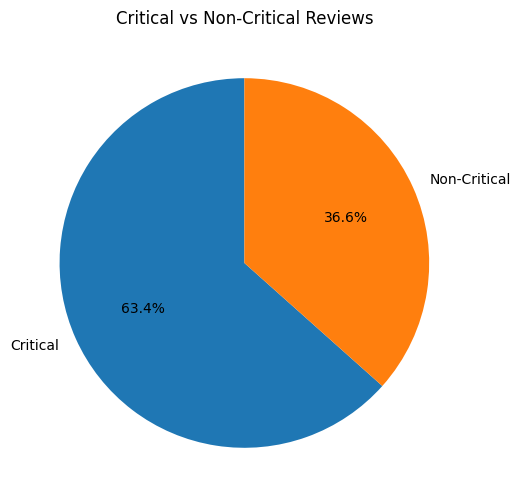

In [93]:
critical = len(df[df["Rating"] <= 2])
non_critical = len(df[df["Rating"] > 2])

plt.figure(figsize=(6,6))
plt.pie(
    [critical, non_critical],
    labels=["Critical", "Non-Critical"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Critical vs Non-Critical Reviews")
plt.show()